# Results

In [28]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load Data

In [29]:
TABLE_NAMES = [
    "successive_halving_no_es",
    "successive_halving_es",
    "hyperband_no_es",
    "hyperband_es",
    "prior_based_sh_no_es",
    "prior_based_sh_es",
    "priorband_no_es",
    "priorband_es",
]
update_data = True

def get_data(table_name: str, update_data: bool) -> pd.DataFrame | None:
    cache_path = f"plain_data/{table_name}/table.csv"
    if update_data:
        try:
            experimenter = PyExperimenter(
                experiment_configuration_file_path="conf/experiment_config.yml",
                database_credential_file_path="conf/database_credentials.yml",
                table_name=table_name,
            )
            df = experimenter.get_table()
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            df.to_csv(cache_path, index=False)
            return df
        except Exception as e:
            print(f"Could not load '{table_name}' from DB: {e}")
            if os.path.exists(cache_path):
                print(f"  Falling back to cached data for '{table_name}'.")
                return pd.read_csv(cache_path)
            return None
    else:
        if not os.path.exists(cache_path):
            print(f"No cache found for '{table_name}', skipping.")
            return None
        return pd.read_csv(cache_path)

dfs = [get_data(t, update_data) for t in TABLE_NAMES]
available = [d for d in dfs if d is not None and not d.empty]

if not available:
    raise RuntimeError("No experiment data found. Run at least one optimizer first.")

df = pd.concat(available, ignore_index=True)
df = df[df["status"] == "done"]
df_lcbench = df[df["benchmark"] == "lcbench"]
print(f"{len(df_lcbench)} completed lcbench experiments")
df_lcbench.head()


2026-04-28 16:15:25,050  | py-experimenter - INFO     | Found 14 keyfields
2026-04-28 16:15:25,051  | py-experimenter - INFO     | Found 6 resultfields
2026-04-28 16:15:25,051  | py-experimenter - INFO     | Found 2 logtables
2026-04-28 16:15:25,051  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-04-28 16:15:25,052  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-04-28 16:15:25,052  | py-experimenter - WARNING  | No custom section defined in config
2026-04-28 16:15:25,052  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-04-28 16:15:25,059  | py-experimenter - INFO     | Initialized and connected to database


2026-04-28 16:15:25,093  | py-experimenter - INFO     | Found 14 keyfields
2026-04-28 16:15:25,093  | py-experimenter - INFO     | Found 6 resultfields
2026-04-28 16:15:25,093  | py-experimenter - INFO     | Found 2 logtables
2026-04-28 16:15:25,094  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-04-28 16:15:25,094  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-04-28 16:15:25,094  | py-experimenter - WARNING  | No custom section defined in config
2026-04-28 16:15:25,094  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-04-28 16:15:25,100  | py-experimenter - INFO     | Initialized and connected to database
2026-04-28 16:15:25,372  | py-experimenter - INFO     | Found 14 keyfields
2026-04-28 16:15:25,373  | py-experimenter - INFO     | Found 6 resultfields
2026-04-28 16:15:25,373  | py-experimenter - INFO     | Found 2 logtables
2026-04-28 16:15:25,374  | py-experimenter - INFO     | Found logtabl

Could not load 'prior_based_sh_no_es' from DB: Execution failed on sql 'SELECT * FROM prior_based_sh_no_es': (1146, "Table 'priorbai_neurips.prior_based_sh_no_es' doesn't exist")
Could not load 'prior_based_sh_es' from DB: Execution failed on sql 'SELECT * FROM prior_based_sh_es': (1146, "Table 'priorbai_neurips.prior_based_sh_es' doesn't exist")
Could not load 'priorband_no_es' from DB: Execution failed on sql 'SELECT * FROM priorband_no_es': (1146, "Table 'priorbai_neurips.priorband_no_es' doesn't exist")
Could not load 'priorband_es' from DB: Execution failed on sql 'SELECT * FROM priorband_es': (1146, "Table 'priorbai_neurips.priorband_es' doesn't exist")
14938 completed lcbench experiments


,ID,run_id,optimizer,num_arms,benchmark,kernel,use_predicted_y,use_early_stopping,seed,dataset_id,...,name,machine,T_max,consumed_budget,remaining_arms,num_epsilon_optimal_arms,regret,epsilon_optimal,end_date,error
0,1,__AUTO__,successive_halving,256,lcbench,linear,0,0,0,0,...,PyExperimenter,cn1202,52.0,1152.0,1.0,16.0,0.0,1.0,2026-04-28 09:58:00,None
1,2,__AUTO__,successive_halving,256,lcbench,linear,0,0,1,0,...,PyExperimenter,cn1302,52.0,1152.0,1.0,25.0,0.0,1.0,2026-04-28 09:58:13,None
2,3,__AUTO__,successive_halving,256,lcbench,linear,0,0,2,0,...,PyExperimenter,cn0936,52.0,1152.0,1.0,20.0,0.0,1.0,2026-04-28 09:58:09,None
3,4,__AUTO__,successive_halving,256,lcbench,linear,0,0,3,0,...,PyExperimenter,cn1502,52.0,1152.0,1.0,20.0,0.0,1.0,2026-04-28 09:57:59,None
4,5,__AUTO__,successive_halving,256,lcbench,linear,0,0,4,0,...,PyExperimenter,cn1502,52.0,1152.0,1.0,21.0,0.0,1.0,2026-04-28 09:57:59,None


## Prepare Data

In [30]:
PRIOR_RENAME = {
    "uniform": "Uniform",
    "performance": "Performance",
    "rank": "Rank",
    "inverse_rank": "Inverse Rank",
    "indicator": "Indicator",
}

BASELINE_LABEL = "Baseline"

_tab10 = sns.color_palette("tab10", n_colors=6)
PRIOR_COLOR_MAP = {
    "Rank": _tab10[0],
    "Performance": _tab10[1],
    "Indicator": _tab10[2],
    "Inverse Rank": _tab10[3],
    "Uniform": _tab10[4],
    BASELINE_LABEL: _tab10[5],
}

def prepare_data(df: pd.DataFrame, optimizer: str) -> pd.DataFrame | None:
    """Method variants (use_early_stopping=1) + baseline (uniform, no early stopping)."""
    method = df[(df["optimizer"] == optimizer) & (df["use_early_stopping"] == 1)].copy()
    baseline = df[
        (df["optimizer"] == optimizer)
        & (df["prior_kind"] == "uniform")
        & (df["use_early_stopping"] == 0)
    ].copy()
    if method.empty and baseline.empty:
        print(f"No data for optimizer '{optimizer}', skipping.")
        return None
    baseline["prior_kind"] = BASELINE_LABEL
    combined = pd.concat([method, baseline], ignore_index=True)
    combined["prior_kind"] = combined["prior_kind"].map(PRIOR_RENAME).fillna(combined["prior_kind"])
    return combined


## Plot

In [31]:
def pareto_plot(data: pd.DataFrame, title: str, xlim=None, ylim=None) -> plt.Figure:
    sns.set_theme(style="whitegrid", context="talk")

    ranked_priors = (
        data.groupby("prior_kind")["consumed_budget"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    if BASELINE_LABEL in ranked_priors:
        ranked_priors = [p for p in ranked_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]

    palette = sns.color_palette("tab10", n_colors=len(ranked_priors))
    markers = ["o", "s", "D", "^", "v", "P", "X", "*"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, prior in enumerate(ranked_priors):
        subset = data[data["prior_kind"] == prior]
        m_reg = subset["regret"].mean()
        s_reg = subset["regret"].sem()
        m_bud = subset["consumed_budget"].mean()
        s_bud = subset["consumed_budget"].sem()

        is_baseline = prior == BASELINE_LABEL
        ax.errorbar(
            m_bud, m_reg,
            xerr=s_bud, yerr=s_reg,
            fmt=markers[i % len(markers)],
            label=prior,
            color=palette[i],
            markersize=9,
            capsize=3,
            markeredgewidth=2,
            alpha=0.6 if is_baseline else 0.9,
            linestyle="--" if is_baseline else "-",
        )

    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("Regret")
    ax.set_title(title)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=True,
    )
    plt.tight_layout()
    return fig


## LCBench

### Sigma Ablation

In [32]:
def sigma_ablation_plot(df: pd.DataFrame, optimizer: str, title: str) -> plt.Figure | None:
    data = df[(df["optimizer"] == optimizer) & (df["use_early_stopping"] == 1)].copy()
    data["prior_kind"] = data["prior_kind"].map(PRIOR_RENAME).fillna(data["prior_kind"])
    data["sigma0"] = data["sigma0"].astype(str)
    if data.empty:
        print(f"No early-stopping data for optimizer '{optimizer}', skipping sigma ablation.")
        return None

    TITLE_SIZE = 14
    LABEL_SIZE = 13
    TICK_SIZE = 11

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, metric, ylabel in zip(
        axes,
        ["regret", "consumed_budget"],
        ["Regret", "Consumed Budget"],
    ):
        sns.boxplot(
            data=data,
            x="prior_kind",
            y=metric,
            hue="sigma0",
            ax=ax,
            palette="Set2",
        )
        ax.set_title(f"{ylabel}: {title}", fontsize=TITLE_SIZE)
        ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
        ax.set_xlabel(None)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=TICK_SIZE)
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")
        if ax.get_legend():
            ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(labels),
        title="sigma0",
        fontsize=TICK_SIZE,
        title_fontsize=LABEL_SIZE,
        frameon=True,
    )
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    return fig


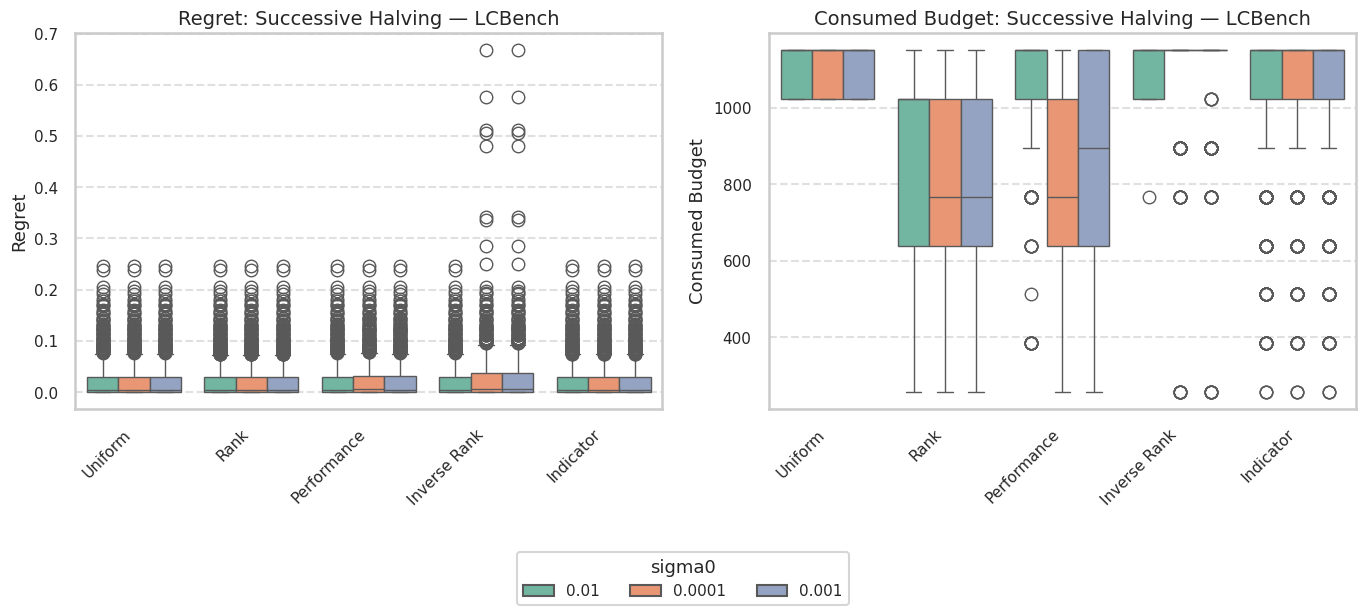

In [33]:
fig = sigma_ablation_plot(df_lcbench, "successive_halving", "Successive Halving — LCBench")
if fig is not None:
    os.makedirs("plots", exist_ok=True)
    fig.savefig("plots/sh_lcbench_sigma_ablation.pdf", bbox_inches="tight")
    fig.savefig("plots/sh_lcbench_sigma_ablation.png", bbox_inches="tight", dpi=300)
    plt.show()


### Successive Halving

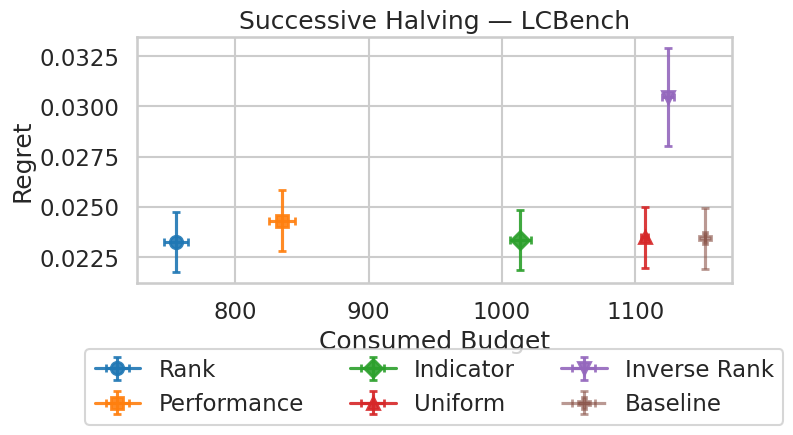

In [34]:
sh_lcbench = prepare_data(df_lcbench, "successive_halving")
if sh_lcbench is not None:
    sh_lcbench = sh_lcbench[(sh_lcbench["sigma0"] == 0.0001) | (sh_lcbench["prior_kind"] == BASELINE_LABEL)]
    os.makedirs("plots", exist_ok=True)
    fig = pareto_plot(sh_lcbench, "Successive Halving — LCBench")
    fig.savefig("plots/sh_lcbench.pdf", bbox_inches="tight")
    fig.savefig("plots/sh_lcbench.png", bbox_inches="tight", dpi=300)
    plt.show()


### Hyperband

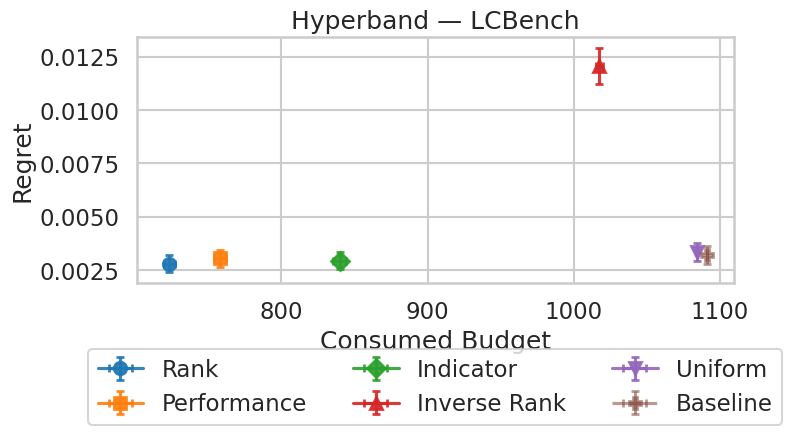

In [35]:
hb_lcbench = prepare_data(df_lcbench, "hyperband")
if hb_lcbench is not None:
    os.makedirs("plots", exist_ok=True)
    fig = pareto_plot(hb_lcbench, "Hyperband — LCBench")
    fig.savefig("plots/hb_lcbench.pdf", bbox_inches="tight")
    fig.savefig("plots/hb_lcbench.png", bbox_inches="tight", dpi=300)
    plt.show()


### PriorBand

In [36]:
pb_lcbench = prepare_data(df_lcbench, "priorband")
if pb_lcbench is not None:
    os.makedirs("plots", exist_ok=True)
    fig = pareto_plot(pb_lcbench, "PriorBand — LCBench")
    fig.savefig("plots/pb_lcbench.pdf", bbox_inches="tight")
    fig.savefig("plots/pb_lcbench.png", bbox_inches="tight", dpi=300)
    plt.show()


No data for optimizer 'priorband', skipping.
